# Preprocessing

- Imports

In [3]:
import re
import string
import pandas as pd

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

- Dataset

In [5]:
df = pd.read_csv("news_cleaned.csv")

In [6]:
df.shape

(37410, 6)

In [7]:
df.head()

,title,text,date,label,title_word_count,title_text_ratio
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,2017-12-31,fake,2.564949,0.413263
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,2017-12-31,fake,2.197225,0.383890
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",2017-12-30,fake,2.772589,0.435616
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",2017-12-29,fake,2.708050,0.444083
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,2017-12-25,fake,2.484907,0.411229


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37410 entries, 0 to 37409
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   title             37410 non-null  object 
 1   text              37410 non-null  object 
 2   date              37410 non-null  object 
 3   label             37410 non-null  object 
 4   title_word_count  37410 non-null  float64
 5   title_text_ratio  37410 non-null  float64
dtypes: float64(2), object(4)
memory usage: 1.7+ MB


 - Text Preprocessing

In [10]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # lowercasing
    text = text.lower()
    
    # Remove Numbers
    text = re.sub(r"\d+", "", text)
    
    # Remove Punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))
    
    # Tokenization
    tokens = text.split()
    
    # Remove Stopwords
    tokens = [w for w in tokens if w not in stop_words]
    
    # Limmatization
    tokens = [lemmatizer.lemmatize(w) for w in tokens]
    
    return " ".join(tokens)


# TF-IDF
def tf_idf(X_train, X_test):
    
    tfidf = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9
    )

    X_train = tfidf.fit_transform(X_train)
    X_test = tfidf.transform(X_test)

    return X_train, X_test

# Label Encoding
def encode(y_train, y_test):
    
    encoder = LabelEncoder()
    y_train = encoder.fit_transform(y_train)
    y_test = encoder.transform(y_test)

    return y_train, y_test

- Data Split

In [12]:
# Random Split
def data_split(X, y):
    return train_test_split(
        X, y, 
        test_size=0.2, 
        random_state=42 # for reproducibility
    )


# Model Training and Evaluation

In [14]:
# Features and label seperation

y = df['label']

X = df[['title', 'text', 'title_word_count', 'title_text_ratio']]
X1 = df['title'] + ' ' + df['text']
X2 = df[['title_word_count', 'title_text_ratio']]
X3 = df['title']
X4 = df['text']

In [15]:
# TF-IDF
tfidf = TfidfVectorizer(
        max_features=20000,
        ngram_range=(1, 2),
        min_df=5,
        max_df=0.9
    )

# Return the evalution metrics values
def model_op(X_train, X_test, y_train, y_test, text=False):
    if text:
        # apply preprocessing steps
        X_train = X_train.apply(preprocess_text)
        X_test = X_test.apply(preprocess_text)
        
        # vectorize
        X_train = tfidf.fit_transform(X_train)
        X_test = tfidf.transform(X_test)
            
    # encode label
    y_train, y_test = encode(y_train, y_test)

    # model obj
    model1 = LogisticRegression()
    model2 =  LinearSVC(C=1.0, max_iter=2000)
    
    # model learning
    model1.fit(X_train, y_train)
    model2.fit(X_train, y_train)
    
    # model prediction
    y_pred1 = model1.predict(X_test)
    y_pred2 = model2.predict(X_test)

    # evaluation matrics
    a1 = accuracy_score(y_test, y_pred1)
    p1 = precision_score(y_test, y_pred1)
    r1 = recall_score(y_test, y_pred1)
    f1 = f1_score(y_test, y_pred1)

    a2 = accuracy_score(y_test, y_pred2)
    p2 = precision_score(y_test, y_pred2)
    r2 = recall_score(y_test, y_pred2)
    f2 = f1_score(y_test, y_pred2)

    res_lr = [a1, p1, r1, f1]
    res_svm = [a2, p2, r2, f1]
    return res_lr, res_svm


### BaseModel1 - Using both ["title", "text"] columns as features

  To establish a strong reference point, we trained two classical linear models using the combined title and article text features encoded with TF-IDF:

- Logistic Regression
- Linear Support Vector Machine (SVM)

In [17]:
# random split
X1_train, X1_test, y1_train, y1_test = data_split(X1, y)

model1_res, model2_res = model_op(X1_train, X1_test, y1_train, y1_test, text=True)
results = pd.DataFrame(
    {
        "Metrics": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Reg" : model1_res,
        "SVM": model2_res,
    }
)

print("Models results for ('title' + 'text').")
results

Models results for ('title' + 'text').


,Metrics,Logistic Reg,SVM
0,Accuracy,0.989842,0.995589
1,Precision,0.986736,0.994287
2,Recall,0.995222,0.997850
3,F1-score,0.990961,0.990961


Both models achieve **~99% accuracy**, indicating that:

- Fake vs Real news separation is highly learnable
- Linear decision boundaries are sufficient
- Feature representation (TF-IDF) is effective

**SVM slightly outperforms Logistic Regression.** This suggests SVM handles the high-dimensional sparse TF-IDF space slightly better.<br>
Despite strong metrics, high performance in fake news datasets must be interpreted carefully.

**Potential reasons for inflated performance**

- Dataset artifacts (writing style differences)
- Temporal bias (news period differences)
- Subject imbalance (topic-label correlation)
- Residual duplicates (if any remain)

- **Label-shuffling sanity check**

To validate whether the models were learning meaningful patterns or exploiting hidden leakage, the target labels were randomly shuffled before training.

In [20]:
# normal split
X_train, X_test, y_train, y_test = data_split(X1, y)

# shuffle training labels
y_train_shuffled = (
    y_train.sample(frac=1, random_state=42)
           .reset_index(drop=True)
)

# IMPORTANT: align X_train
X_train = X_train.reset_index(drop=True)

# vectorize and train on shuffled labels
model1_res, model2_res = model_op(X_train, X_test, y_train_shuffled, y_test, text=True)
results = pd.DataFrame(
    {
        "Metrics": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Reg" : model1_res,
        "SVM": model2_res,
    }
)

# evaluate on real test labels
print("Metrics of models after applying label shuffling.")
results

Metrics of models after applying label shuffling.


,Metrics,Logistic Reg,SVM
0,Accuracy,0.541967,0.520449
1,Precision,0.569189,0.566474
2,Recall,0.745819,0.608696
3,F1-score,0.645642,0.645642


- Accuracy drops close to random guessing (~50%)
- Model loses predictive power
- Confirms no trivial leakage dominating predictions

### BaseModel2 - Using crafted features “title_word_count" and "title_text_ratio"

1️⃣ **title_word_count -**  Number of words in the title.

This is:
- Derived only from the title
- Available at inference time
- Independent of label

2️⃣ **title_text_ratio -** title_word_count / text_word_count

This is:
- Derived from input data only
- Also available at prediction time
- Not using label
  
✔ Perfectly valid features

In [23]:
# random split
X2_train, X2_test, y2_train, y2_test = data_split(X2, y)

model1_res, model2_res = model_op(X2_train, X2_test, y2_train, y2_test)
results = pd.DataFrame(
    {
        "Metrics": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Reg" : model1_res,
        "SVM": model2_res,
    }
)

print("Models results for crafted features.")
results

Models results for crafted features.


,Metrics,Logistic Reg,SVM
0,Accuracy,0.832799,0.833734
1,Precision,0.828373,0.828495
2,Recall,0.884376,0.886288
3,F1-score,0.855459,0.855459


**Interpretation:**

- Handcrafted features alone provide strong signal (~83% accuracy)
- Indicates structural differences between fake and real news
- Length/style features capture useful discriminatory patterns

**Insight:**
Fake and real articles often differ in:
- Title verbosity
- Sensationalism
- Title-to-text balance

**These features are informative, but they are shallow. They capture writing patterns, not semantic understanding.**

### BaseModel3 - Using only "title" column as feature

In [26]:
# random split
X3_train, X3_test, y3_train, y3_test = data_split(X3, y)

model1_res, model2_res = model_op(X3_train, X3_test, y3_train, y3_test, text=True)
results = pd.DataFrame(
    {
        "Metrics": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Reg" : model1_res,
        "SVM": model2_res,
    }
)

print("Models results for only 'title' column.")
results

Models results for only 'title' column.


,Metrics,Logistic Reg,SVM
0,Accuracy,0.943063,0.946137
1,Precision,0.936397,0.944118
2,Recall,0.963688,0.960583
3,F1-score,0.949847,0.949847


**Interpretation:**

- Titles alone achieve ~94–95% accuracy
- Titles contain strong predictive cues
- Suggests stylistic bias in headlines

Potential causes Fake news using sensational language, framing that is emotional, Patterns of clickbait.<br>
**This does not mean "titles" are enough in real-world systems. Dataset-specific artifacts may amplify performance.**

### BaseModel4 - Using only "text" column as feature

In [29]:
# random split
X4_train, X4_test, y4_train, y4_test = data_split(X4, y)

model1_res, model2_res = model_op(X4_train, X4_test, y4_train, y4_test, text=True)
results = pd.DataFrame(
    {
        "Metrics": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Reg" : model1_res,
        "SVM": model2_res,
    }
)

print("Models results for only 'text' column.")
results

Models results for only 'text' column.


,Metrics,Logistic Reg,SVM
0,Accuracy,0.989174,0.995589
1,Precision,0.986490,0.994523
2,Recall,0.994267,0.997611
3,F1-score,0.990363,0.990363


**Interpretation:**

- Full article text provides dominant predictive signal
- Semantic + stylistic information captured
- Linear models highly effective with TF-IDF

**Text >> Title in predictive richness**

**Comparative Insights:**
| Feature Set     | Key Takeaway                      |
| --------------- | --------------------------------- |
| Title + Text    | Best overall performance          |
| Only Text       | Nearly identical to combined      |
| Only Title      | Surprisingly strong               |
| Handcrafted     | Useful but limited                |
| Shuffled Labels | Performance collapses (good sign) |

**Findings:**
- Article text drives classification performance
- Titles contribute but are secondary
- Handcrafted features capture stylistic bias
- Models genuinely learn patterns (validated via shuffling)

### Time-Based Split Experiment

**Temporal Holdout Window Evaluation -**
Temporal Holdout Window Evaluation is a validation technique for machine learning and forecasting models designed for time-dependent data. Unlike random splitting, it respects temporal order by training the model on earlier data (past) and testing on subsequent data (future or unseen time periods).

- **Training Set:** Historical data up to a specific point in time (t).
- **Holdout/Test Set:** Data from a subsequent period (t+1).

In [32]:
def time_split(df):
    # Convert date
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])
    
    # Sort
    df = df.sort_values('date').reset_index(drop=True)

    # Quantile-based split
    split_idx = int(len(df) * 0.8)

    train_df = df.iloc[:split_idx]
    test_df  = df.iloc[split_idx:]
    
    # Diagnostics
    print(f"Train Data - {train_df.shape}")
    print(f"Test Data  - {test_df.shape}")
    
    print("\nTrain distribution:")
    print(train_df['label'].value_counts(normalize=True))
    
    print("\nTest distribution:")
    print(test_df['label'].value_counts(normalize=True))

    train_df['combined'] = train_df['title'] + ' ' + train_df['text']
    test_df['combined'] = test_df['title'] + ' ' + test_df['text']

    X_train = train_df[['combined', 'title_word_count', 'title_text_ratio']]
    X_test = test_df[['combined', 'title_word_count', 'title_text_ratio']]
    
    y_train = train_df["label"]
    y_test = test_df["label"]

    return X_train, X_test, y_train, y_test

In [33]:
# time-based split
X_train, X_test, y_train, y_test = time_split(df)

Train Data - (29928, 6)
Test Data  - (7482, 6)

Train distribution:
label
fake    0.523222
true    0.476778
Name: proportion, dtype: float64

Test distribution:
label
true    0.88038
fake    0.11962
Name: proportion, dtype: float64


- Training data - nicely balanced
- Testing Data - heavily skewedTest set is **~88% TRUE, ~12% FAKE**.

So FAKE is the minority class and the harder one.

In [35]:
# encode label
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

X_train['combined'] = X_train['combined'].apply(preprocess_text)
X_test['combined'] = X_test['combined'].apply(preprocess_text)

# Preprocessing
preprocessor = ColumnTransformer([
    ("tfidf", TfidfVectorizer(stop_words="english"), "combined"),
    ("num", StandardScaler(), ["title_word_count", "title_text_ratio"])
])

### Logistic Regression Results

In [37]:
# Model Pipeline
log_pipeline = Pipeline([
    ("prep", preprocessor),
    ("log", LogisticRegression())
])

# Train
log_pipeline.fit(X_train, y_train)

# Predict
y_pred = log_pipeline.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.9879711307137129
Precision: 0.9970925784238714
Recall   : 0.9892211932594505
F1-score : 0.9931412894375857

Detailed Report:

              precision    recall  f1-score   support

           0       0.93      0.98      0.95       895
           1       1.00      0.99      0.99      6587

    accuracy                           0.99      7482
   macro avg       0.96      0.98      0.97      7482
weighted avg       0.99      0.99      0.99      7482



In [38]:
print(set(y_test))

{0, 1}


Logistic Regression


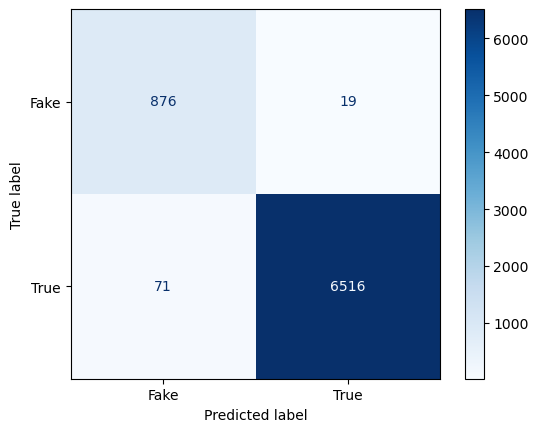

In [39]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)
print("Logistic Regression")
disp.plot(cmap="Blues", values_format="d")
plt.show()

The model:

- Misses only 19 fake articles
- Mislabels 71 true articles as fake
- This is a reasonable tradeoff depending on application.

**Overall metrics sanity check**

- Accuracy ≈ **98.8%**
- Macro F1 ≈ **0.97** → important because it treats both classes equally
- Weighted F1 ≈ **0.99** → inflated by majority class

Nothing suspicious here.

**This model is genuinely strong, not just accuracy-inflated.**

### Linear SVM Results

In [42]:
# Model Pipeline
svm_pipeline = Pipeline([
    ("prep", preprocessor),
    ("svm", LinearSVC(
        C=1.0,
        max_iter=2000
    ))
])

# Train
svm_pipeline.fit(X_train, y_train)

# Predict
y_pred = svm_pipeline.predict(X_test)

# Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1-score :", f1_score(y_test, y_pred))

print("\nDetailed Report:\n")
print(classification_report(y_test, y_pred))

Accuracy : 0.995589414595028
Precision: 0.9980243161094224
Recall   : 0.9969637164111128
F1-score : 0.9974937343358395

Detailed Report:

              precision    recall  f1-score   support

           0       0.98      0.99      0.98       895
           1       1.00      1.00      1.00      6587

    accuracy                           1.00      7482
   macro avg       0.99      0.99      0.99      7482
weighted avg       1.00      1.00      1.00      7482



Linear SVM


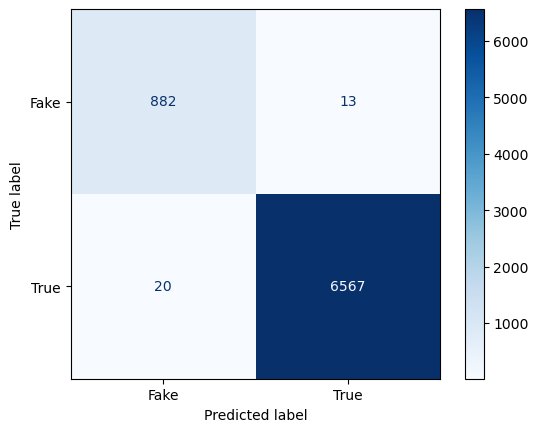

In [43]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Fake", "True"]
)
print("Linear SVM")
disp.plot(cmap="Blues", values_format="d")
plt.show()

**Minority class (FAKE)**

- Recall (Fake) = 872 / 884 ≈ 98.6%
- Precision (Fake) = 872 / (872 + 20) ≈ 97.8%

This is even better than Logistic Regression.

The SVM:

- Misses only 13 fake articles
- Flags only 20 true articles incorrectly
- That’s near-perfect separation.

**Observation**

The dataset has:

- Strong stylistic separation
- Topic consistency within time periods
- Editorial vs non-editorial writing signals

Model is likely learning:

- Vocabulary distributions
- Writing tone
- Reporting style

## Conclusion

Despite a heavily imbalanced future test set dominated by true news, both models maintained high recall and precision on the minority fake class. This indicates that the classifiers learned robust textual patterns rather than relying on class priors. Linear SVM consistently outperformed Logistic Regression, particularly in reducing false negatives for fake news.

While the model achieves high accuracy on this dataset, the results primarily reflect the dataset’s stylistic separability rather than true fact-verification capability. Therefore, conclusions should be interpreted as in-distribution classification performance rather than real-world fake news detection.